In [2]:
%pip install numpy matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 32.4 MB/s  0:00:00
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 26.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, sqrt, log

np.random.seed(42)

N = 1000
K = 2
DELTAS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
NUM_SIMS = 100

In [14]:
def generate_rewards(delta, n, rng):
    rewards = np.empty((K, n))
    rewards[0] = rng.normal(loc=0.0, scale=1.0, size=n)
    rewards[1] = rng.normal(loc=-delta, scale=1.0, size=n)
    return rewards

In [15]:
def explore_then_commit(rewards, n):
    m = ceil(n ** (2.0 / 3.0))
    arms_pulled = np.empty(n, dtype=int)

    #explore
    for arm in range(K):
        arms_pulled[arm * m : (arm + 1) * m] = arm

    # get empirical means
    exploration_end = K * m
    means = np.array([rewards[arm, :m].mean() for arm in range(K)])
    optimal_arm_estimate = np.argmax(means)

    #commit
    arms_pulled[exploration_end:] = optimal_arm_estimate

    return arms_pulled

def epsilon_greedy(rewards, n, rng, c=50):
    arms_pulled = np.empty(n, dtype=int)
    pulls = np.zeros(K, dtype=int)
    reward_sums = np.zeros(K)

    for t in range(1, n + 1):
        eps = min(1.0, c / t)

        if rng.random() < eps:
            arm = rng.integers(K)
        else:
            means_hat = np.where(pulls > 0, reward_sums / pulls, np.inf)
            arm = np.argmax(means_hat)

        idx = t - 1
        arms_pulled[idx] = arm
        reward_sums[arm] += rewards[arm, pulls[arm]]
        pulls[arm] += 1

    return arms_pulled


def successive_elimination(rewards, n):
    active = np.ones(K, dtype=bool)
    arms_pulled = np.empty(n, dtype=int)
    pulls = np.zeros(K, dtype=int)
    reward_sums = np.zeros(K)
    t = 0

    while t < n:
        active_arms = np.where(active)[0]

        #Play each active arm once
        for arm in active_arms:
            if t >= n:
                break
            arms_pulled[t] = arm
            reward_sums[arm] += rewards[arm, pulls[arm]]
            pulls[arm] += 1
            t += 1

        #Check elim condition
        if active.sum() > 1:
            means_hat = np.where(pulls > 0, reward_sums / pulls, 0.0)
            bonus = np.where(pulls > 0, np.sqrt(2 * log(n) / pulls), np.inf)
            ucb = means_hat + bonus
            lcb = means_hat - bonus

            max_lcb = np.max(lcb[active])
            for arm in np.where(active)[0]:
                if ucb[arm] < max_lcb:
                    active[arm] = False

        # If only one arm left, fill remaining rounds
        if active.sum() == 1 and t < n:
            sole_arm = np.where(active)[0][0]
            arms_pulled[t:] = sole_arm
            t = n

    return arms_pulled




In [16]:
def compute_regret(arms_pulled, delta):
    return delta * np.sum(arms_pulled != 0)


def run_simulations(algo_fn, delta, n, num_sims, needs_rng=False):
    regrets = np.empty(num_sims)
    for s in range(num_sims):
        rng = np.random.default_rng(seed=s * 1000 + int(delta * 100))
        rewards = generate_rewards(delta, n, rng)
        if needs_rng:
            arms_pulled = algo_fn(rewards, n, rng)
        else:
            arms_pulled = algo_fn(rewards, n)
        regrets[s] = compute_regret(arms_pulled, delta)
    mean_regret = regrets.mean()
    std_error = regrets.std(ddof=1) / sqrt(num_sims)
    return mean_regret, std_error


algorithms = {
    "ETC": (explore_then_commit, False),
    "epsilon-greedy": (epsilon_greedy, True),
    "Successive Elimination": (successive_elimination, False),
}

results = {name: {"means": [], "ses": []} for name in algorithms}

for name, (algo_fn, needs_rng) in algorithms.items():
    for delta in DELTAS:
        mean_r, se_r = run_simulations(algo_fn, delta, N, NUM_SIMS, needs_rng)
        results[name]["means"].append(mean_r)
        results[name]["ses"].append(se_r)
    print("checkpoint")

print("done")

checkpoint
checkpoint
checkpoint
done


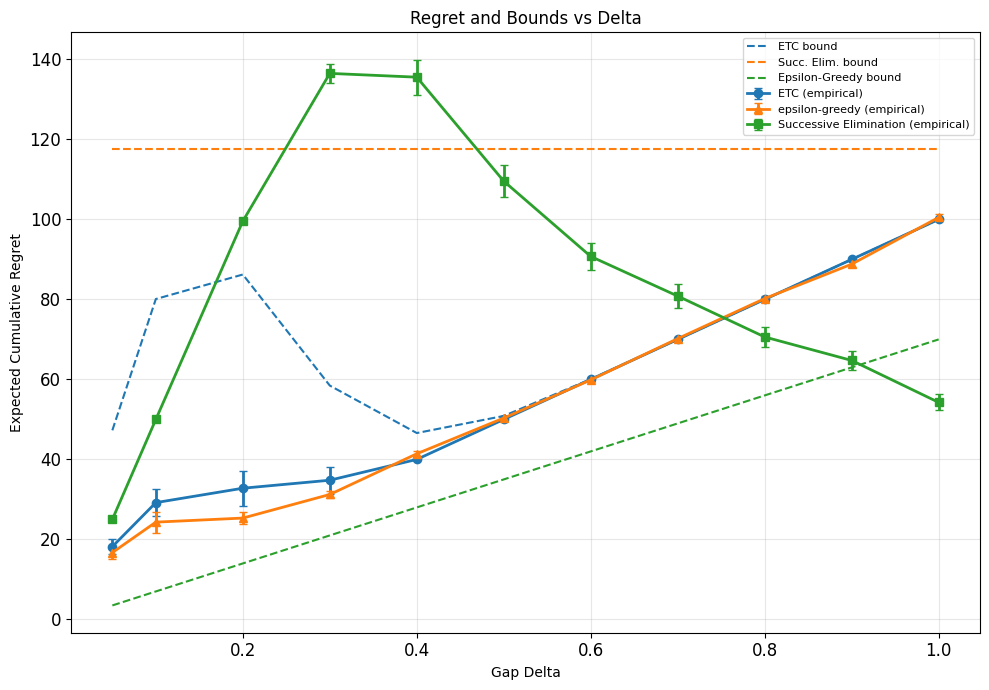

In [ ]:
m = ceil(N ** (2.0 / 3.0))
c = 50
markers = {"ETC": "o", "epsilon-greedy": "^", "Successive Elimination": "s"}

def etc_bound(delta, n, m):
    return delta * m + delta * (n - m) * np.exp(-m * delta**2 / 4)

def se_bound(n):
    return sqrt(K * n * log(n))

def eps_greedy_bound(delta, n, c):
    return c * delta + delta * n / c

bounds_etc = [etc_bound(d, N, m) for d in DELTAS]
bounds_se = [se_bound(N)] * len(DELTAS)
bounds_eg = [eps_greedy_bound(d, N, c) for d in DELTAS]

fig, ax = plt.subplots(figsize=(10, 7))

for name in algorithms:
    means = results[name]["means"]
    ses = results[name]["ses"]
    ax.errorbar(
        DELTAS, means, yerr=ses,
        label=f"{name} (empirical)",
        marker=markers[name], capsize=3, linewidth=2,
    )

ax.plot(DELTAS, bounds_etc, "--", color="C0", linewidth=1.5, label="ETC bound")
ax.plot(DELTAS, bounds_eg, "--", color="C2", linewidth=1.5, label="Epsilon-Greedy bound")
ax.plot(DELTAS, bounds_se, "--", color="C1", linewidth=1.5, label="Succ. Elim. bound")

ax.set_xlabel("Gap Delta")
ax.set_ylabel("Expected Cumulative Regret")
ax.set_title("Regret and Bounds vs Delta")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()